In [64]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib import cm
import sympy

In [65]:
# Usando numpy resolvemos el sistema de ecuaciones del ejemplo
A = np.array([[1,0,1,-0.5],[1,0,-1,0],[0,1,-0.7,2],[0,1,0,-1.5]])
b = np.array((10,0,20,0)).reshape(4,1)
print('A ='); print(A)
print('\nb =', b.flatten())

x=np.linalg.solve(A,b)
print('\nSolución x =')
# Opción 2: indexar con doble índice
print(f'q1={x[0,0]:.2f}, q2={x[1,0]:.2f}, p1={x[2,0]:.2f}, p2={x[3,0]:.2f}')

A =
[[ 1.   0.   1.  -0.5]
 [ 1.   0.  -1.   0. ]
 [ 0.   1.  -0.7  2. ]
 [ 0.   1.   0.  -1.5]]

b = [10  0 20  0]

Solución x =
q1=6.77, q2=10.60, p1=6.77, p2=7.07


In [66]:
def check_independence(*vectors):
    
    A=np.column_stack(vectors)
    r=np.linalg.matrix_rank(A)
    if r==len(vectors):
        print('Los vectores son linealmente independientes')
    else:
        print('Los vectores son linealmente dependientes')
        print(f'solamente hay {r} vectores linealmente independientes')

A = np.array([15, 3])
B = np.array([9, 11])
C = np.array([48, 28])
check_independence(A, B)

Los vectores son linealmente independientes


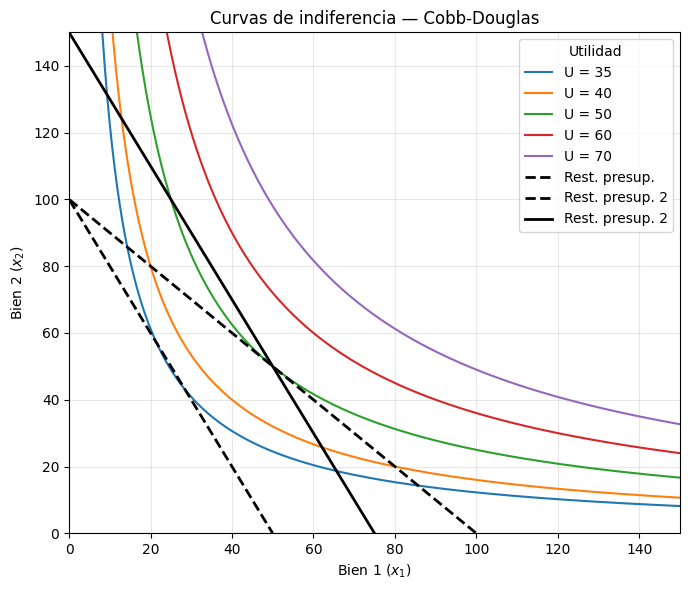

In [67]:
import numpy as np
import matplotlib.pyplot as plt

alpha = 0.5 
beta = 0.5
niveles_U = [35,40,50,60,70]   # distintas curvas de indiferencia

x1 = np.linspace(0.1, 150, 500) #crea 500 puntos entre 0.1 y 10 

fig, ax = plt.subplots(figsize=(7, 6))

for U0 in niveles_U:
    x2 = (U0**(1/beta) * x1**(-alpha/beta))  # despejamos x2 de la función de utilidad
    ax.plot(x1, x2, label=f'U = {U0}')

# Restricción presupuestaria: p1*x1 + p2*x2 = I
p1, p2, I = 1, 1, 100  # recta va de (0,200) a (200,0)
x2_rp = (I - p1 * x1) / p2
mask = (x2_rp >= 0) & (x1 <= I / p1)
ax.plot(x1[mask], x2_rp[mask], 'k--', linewidth=2, label='Rest. presup.')
ax.legend()


p1, p2, I = 2, 1, 100  # recta va de (0,200) a (200,0)
x2_rp = (I - p1 * x1) / p2
mask = (x2_rp >= 0) & (x1 <= I / p1)
ax.plot(x1[mask], x2_rp[mask], 'k--', linewidth=2, label='Rest. presup. 2')
ax.legend()

p1, p2, I = 2, 1, 150  # recta va de (0,200) a (200,0)
x2_rp = (I - p1 * x1) / p2
mask = (x2_rp >= 0) & (x1 <= I / p1)
ax.plot(x1[mask], x2_rp[mask], 'k-', linewidth=2, label='Rest. presup. 2')
ax.legend()

ax.set_xlim(0, 150)
ax.set_ylim(0, 150)
ax.set_xlabel('Bien 1 ($x_1$)')
ax.set_ylabel('Bien 2 ($x_2$)')
ax.set_title('Curvas de indiferencia — Cobb-Douglas')
ax.legend(title='Utilidad')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [84]:
(0.25**0.5)+19.75


20.25

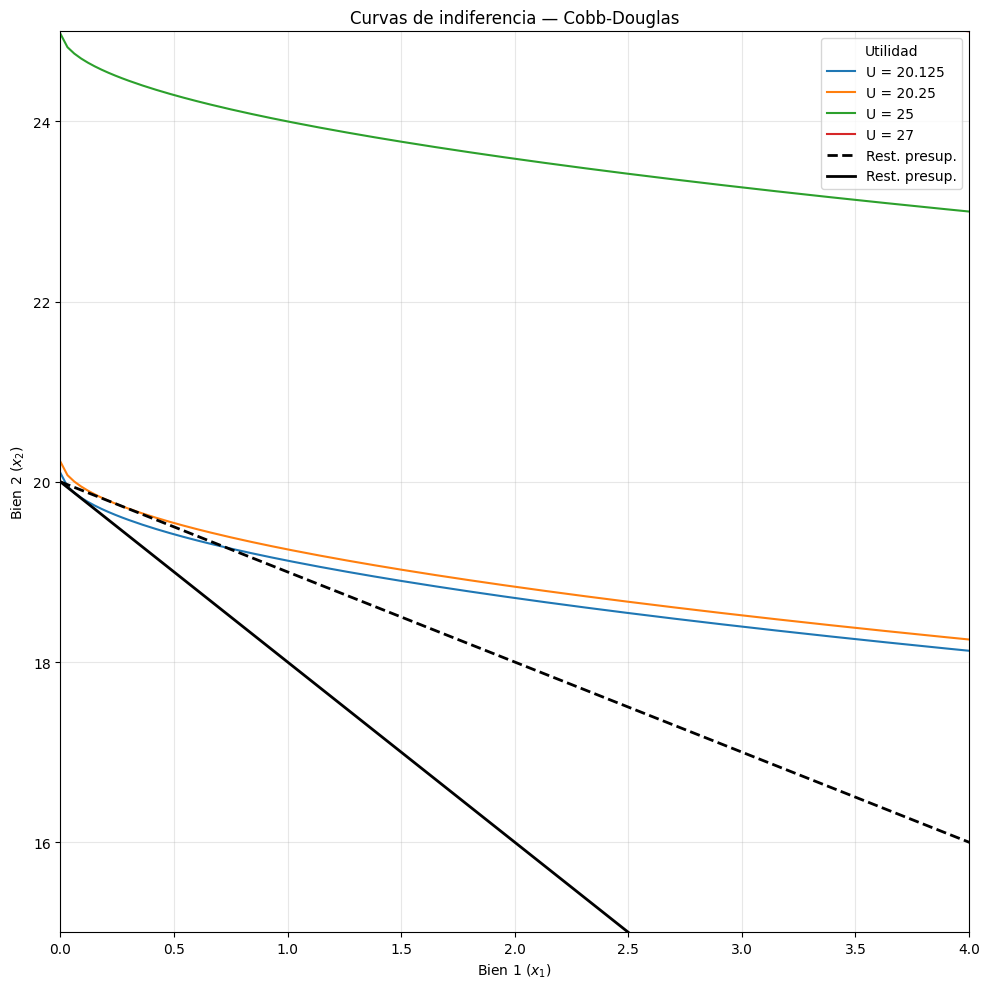

In [102]:
import numpy as np
import matplotlib.pyplot as plt

alpha = 0.5 
beta = 0.5
niveles_U = [20.125,20.25,25,27]   # distintas curvas de indiferencia

x1 = np.linspace(0.001, 150, 5000) #crea 500 puntos entre 0.1 y 10 

fig, ax = plt.subplots(figsize=(10, 10))

for U0 in niveles_U:
    x2 = U0-x1**(alpha) # despejamos x2 de la función de utilidad
    ax.plot(x1, x2, label=f'U = {U0}')

# Restricción presupuestaria: p1*x1 + p2*x2 = I
p1, p2, I = 1, 1, 20  # recta va de (0,200) a (200,0)
x2_rp = (I - p1 * x1) / p2
mask = (x2_rp >= 0) & (x1 <= I / p1)
ax.plot(x1[mask], x2_rp[mask], 'k--', linewidth=2, label='Rest. presup.')
ax.legend()


# Restricción presupuestaria: p1*x1 + p2*x2 = I
p1, p2, I = 2, 1, 20  # recta va de (0,200) a (200,0)
x2_rp = (I - p1 * x1) / p2
mask = (x2_rp >= 0) & (x1 <= I / p1)
ax.plot(x1[mask], x2_rp[mask], 'k-', linewidth=2, label='Rest. presup.')
ax.legend()


ax.set_xlim(0, 4)
ax.set_ylim(15, 25)
ax.set_xlabel('Bien 1 ($x_1$)')
ax.set_ylabel('Bien 2 ($x_2$)')
ax.set_title('Curvas de indiferencia — Cobb-Douglas')
ax.legend(title='Utilidad')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [137]:
1/16*2+20


20.125

In [135]:
20.25-(0.0625)**0.5

20.0

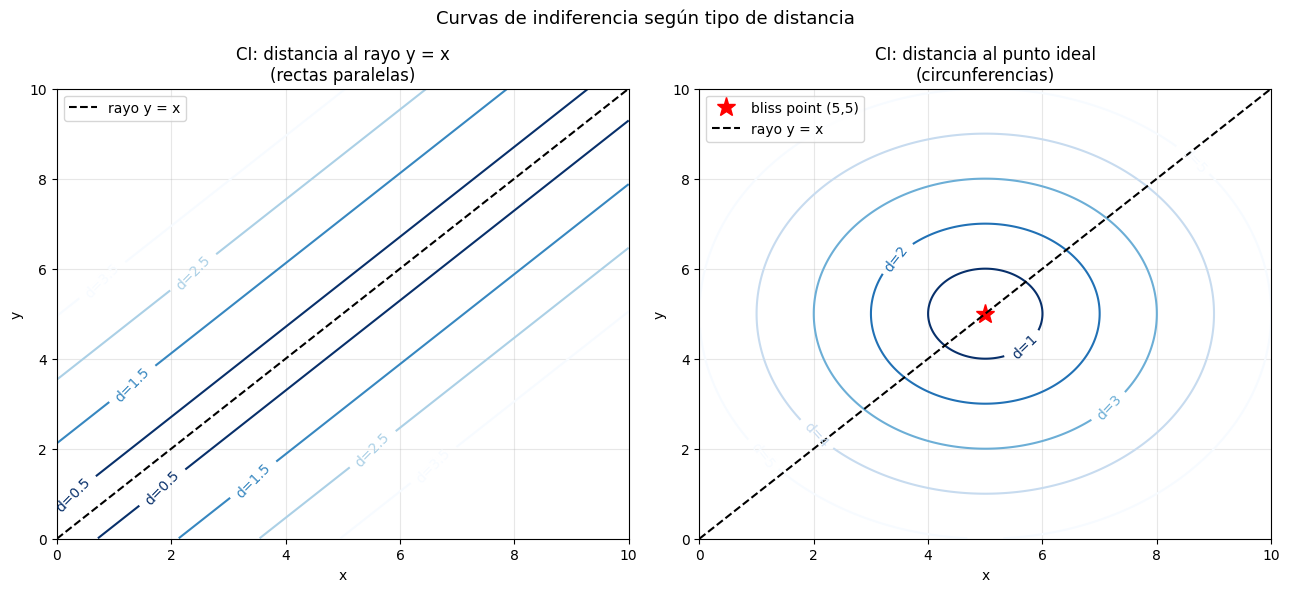

In [69]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

x = np.linspace(0.01, 10, 400)
y = np.linspace(0.01, 10, 400)
X, Y = np.meshgrid(x, y)

# ── Opción 1: distancia al rayo y = x ──────────────────────────
ax1 = axes[0]
D1 = np.abs(Y - X) / np.sqrt(2)
niveles1 = [0.5, 1.5, 2.5, 3.5]
cp1 = ax1.contour(X, Y, D1, levels=niveles1, cmap='Blues_r')
ax1.clabel(cp1, fmt='d=%.1f')
ax1.plot([0, 10], [0, 10], 'k--', linewidth=1.5, label='rayo y = x')
ax1.set_xlim(0, 10); ax1.set_ylim(0, 10)
ax1.set_xlabel('x'); ax1.set_ylabel('y')
ax1.set_title('CI: distancia al rayo y = x\n(rectas paralelas)')
ax1.legend(); ax1.grid(True, alpha=0.3)

# ── Opción 2: distancia al punto ideal ─────────────────────────
ax2 = axes[1]
x_star, y_star = 5, 5          # punto ideal sobre y = x
D2 = np.sqrt((X - x_star)**2 + (Y - y_star)**2)
niveles2 = [1, 2, 3, 4, 5]
cp2 = ax2.contour(X, Y, D2, levels=niveles2, cmap='Blues_r')
ax2.clabel(cp2, fmt='d=%.0f')
ax2.plot(x_star, y_star, 'r*', markersize=14, label=f'bliss point ({x_star},{y_star})')
ax2.plot([0, 10], [0, 10], 'k--', linewidth=1.5, label='rayo y = x')
ax2.set_xlim(0, 10); ax2.set_ylim(0, 10)
ax2.set_xlabel('x'); ax2.set_ylabel('y')
ax2.set_title('CI: distancia al punto ideal\n(circunferencias)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Curvas de indiferencia según tipo de distancia', fontsize=13)
plt.tight_layout()
plt.show()

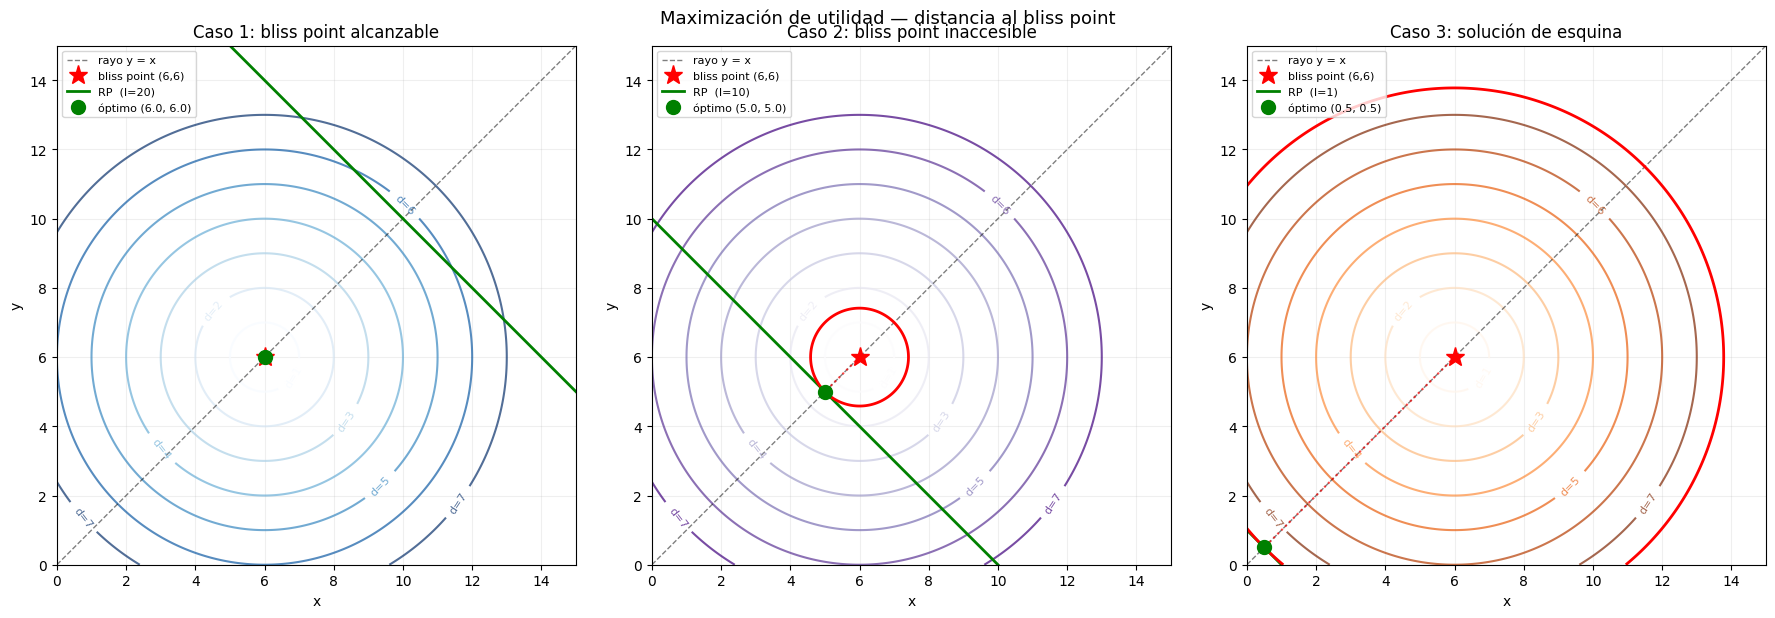

In [70]:
import numpy as np
import matplotlib.pyplot as plt

def proyeccion_sobre_rp(x_star, y_star, p1, p2, I):
    """Proyección ortogonal del bliss point sobre la RP."""
    t = (I - p1*x_star - p2*y_star) / (p1**2 + p2**2)
    x_opt = x_star + p1 * t
    y_opt = y_star + p2 * t
    return x_opt, y_opt

def optimo(x_star, y_star, p1, p2, I):
    """Devuelve el óptimo según el caso."""
    gasto = p1*x_star + p2*y_star
    if gasto <= I:                          # bliss point alcanzable
        return x_star, y_star, 'alcanzable'
    x_opt, y_opt = proyeccion_sobre_rp(x_star, y_star, p1, p2, I)
    if x_opt < 0:                           # esquina en y
        return 0, I/p2, 'esquina_y'
    if y_opt < 0:                           # esquina en x
        return I/p1, 0, 'esquina_x'
    return x_opt, y_opt, 'inaccesible'     # proyección interior

# ── Parámetros ──────────────────────────────────────────────────
p1, p2   = 1, 1
x_star   = 6       # bliss point sobre y = x
y_star   = 6

casos = [
    {'I': 20,  'titulo': 'Caso 1: bliss point alcanzable',   'color_ci': 'Blues'},
    {'I': 10,  'titulo': 'Caso 2: bliss point inaccesible',  'color_ci': 'Purples'},
    {'I': 1,   'titulo': 'Caso 3: solución de esquina',      'color_ci': 'Oranges'},
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

x = np.linspace(0, 15, 400)
y = np.linspace(0, 15, 400)
X, Y = np.meshgrid(x, y)
D = np.sqrt((X - x_star)**2 + (Y - y_star)**2)

for ax, caso in zip(axes, casos):
    I = caso['I']

    # CI
    niveles = [1, 2, 3, 4, 5, 6, 7]
    cp = ax.contour(X, Y, D, levels=niveles, cmap=caso['color_ci'], alpha=0.7)
    ax.clabel(cp, fmt='d=%.0f', fontsize=8)

    # Rayo y = x
    ax.plot([0, 15], [0, 15], 'k--', linewidth=1, alpha=0.5, label='rayo y = x')

    # Bliss point
    ax.plot(x_star, y_star, 'r*', markersize=14, zorder=5, label=f'bliss point ({x_star},{y_star})')

    # Restricción presupuestaria
    x_rp = np.linspace(0, I/p1, 300)
    y_rp = (I - p1 * x_rp) / p2
    ax.plot(x_rp, y_rp, 'g-', linewidth=2, label=f'RP  (I={I})')

    # Óptimo
    x_opt, y_opt, tipo = optimo(x_star, y_star, p1, p2, I)
    ax.plot(x_opt, y_opt, 'go', markersize=10, zorder=6, label=f'óptimo ({x_opt:.1f}, {y_opt:.1f})')

    # Segmento bliss → óptimo
    ax.plot([x_star, x_opt], [y_star, y_opt], 'r:', linewidth=1.5, alpha=0.7)

    # CI tangente en el óptimo
    d_opt = np.sqrt((x_opt - x_star)**2 + (y_opt - y_star)**2)
    ax.contour(X, Y, D, levels=[d_opt], colors='red', linewidths=2)

    ax.set_xlim(0, 15); ax.set_ylim(0, 15)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title(caso['titulo'])
    ax.legend(fontsize=8); ax.grid(True, alpha=0.2)
    ax.set_aspect('equal')

plt.suptitle('Maximización de utilidad — distancia al bliss point', fontsize=13)
plt.tight_layout()
plt.show()

Óptimo: (2.40, 4.80)
Distancia mínima al origen: 5.37


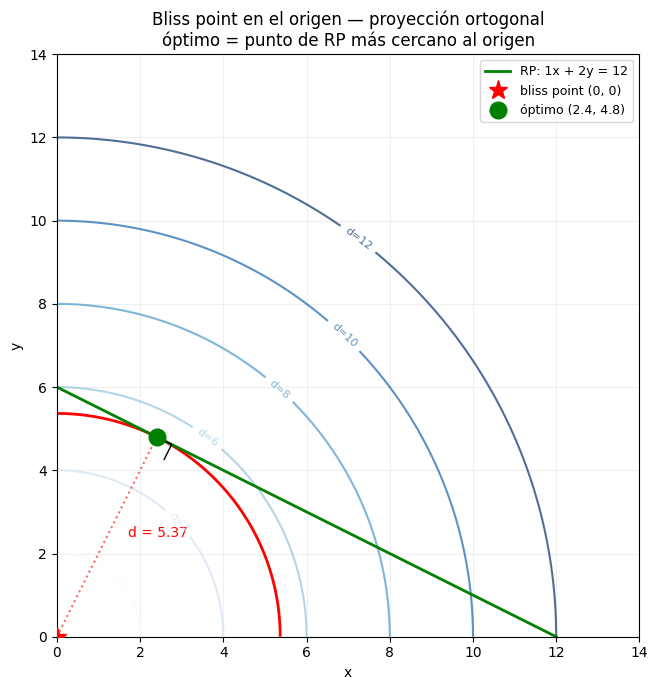

In [75]:
import numpy as np
import matplotlib.pyplot as plt

# ── Parámetros ───────────────────────────────────────────────
x_star, y_star = 0, 0
p1, p2, I      = 1, 2, 12

# ── Proyección ortogonal (caso 2, siempre interior) ──────────
t      = (I - p1*x_star - p2*y_star) / (p1**2 + p2**2)
x_opt  = x_star + p1 * t
y_opt  = y_star + p2 * t
d_opt  = np.sqrt((x_opt - x_star)**2 + (y_opt - y_star)**2)

print(f"Óptimo: ({x_opt:.2f}, {y_opt:.2f})")
print(f"Distancia mínima al origen: {d_opt:.2f}")

# ── Grilla ───────────────────────────────────────────────────
lim = 14
x = np.linspace(0, lim, 500)
y = np.linspace(0, lim, 500)
X, Y = np.meshgrid(x, y)
D = np.sqrt((X - x_star)**2 + (Y - y_star)**2)

# ── Gráfico ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))

# CI
niveles = [2, 4, 6, 8, 10, 12]
cp = ax.contour(X, Y, D, levels=niveles, cmap='Blues', alpha=0.7)
ax.clabel(cp, fmt='d=%.0f', fontsize=8)

# CI tangente en el óptimo
ax.contour(X, Y, D, levels=[d_opt], colors='red', linewidths=2)

# RP
x_rp = np.linspace(0, I/p1, 400)
y_rp = (I - p1 * x_rp) / p2
ax.plot(x_rp, y_rp, 'g-', linewidth=2, label=f'RP: {p1}x + {p2}y = {I}')

# Bliss point
ax.plot(x_star, y_star, 'r*', markersize=14, zorder=5,
        label=f'bliss point ({x_star}, {y_star})')

# Segmento origen → óptimo
ax.plot([x_star, x_opt], [y_star, y_opt], 'r:', linewidth=1.5, alpha=0.6)

# Óptimo
ax.plot(x_opt, y_opt, 'go', markersize=12, zorder=6,
        label=f'óptimo ({x_opt:.1f}, {y_opt:.1f})')

# Ángulo recto en el óptimo (perpendiculariedad)
size = 0.4
dx_rp = p2 / np.sqrt(p1**2 + p2**2)   # dirección paralela a RP
dy_rp = -p1 / np.sqrt(p1**2 + p2**2)
dx_d  = -x_opt / d_opt                 # dirección hacia origen
dy_d  = -y_opt / d_opt
ax.plot([x_opt, x_opt + size*dx_rp, x_opt + size*dx_rp + size*dx_d],
        [y_opt, y_opt + size*dy_rp, y_opt + size*dy_rp + size*dy_d],
        'k-', linewidth=1)

ax.annotate(f'd = {d_opt:.2f}',
            xy=((x_star + x_opt)/2 + 0.5, (y_star + y_opt)/2),
            fontsize=10, color='red')

ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Bliss point en el origen — proyección ortogonal\n'
             f'óptimo = punto de RP más cercano al origen')
ax.legend(fontsize=9); ax.grid(True, alpha=0.2)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

Óptimo: (9.60, 2.40)
Distancia ponderada mínima: 7.59
Ratio x/y = 4.00  (caso circular sería 1.00)


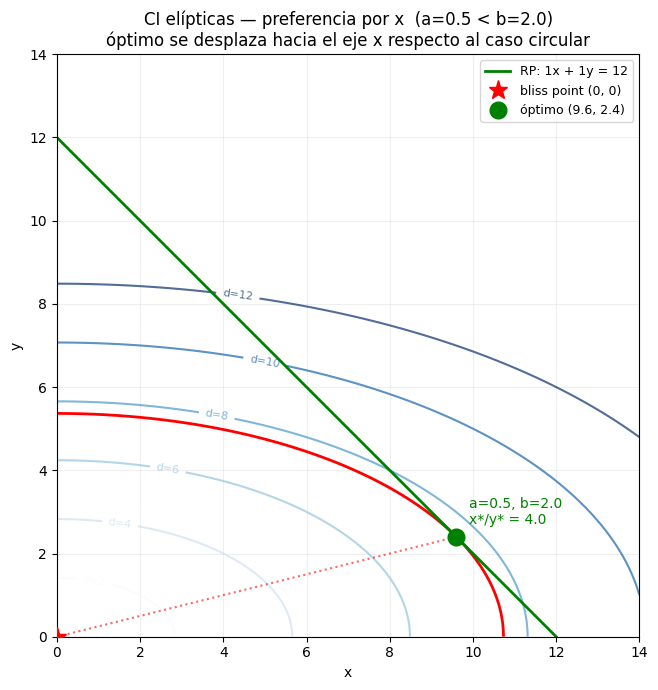

In [76]:
import numpy as np
import matplotlib.pyplot as plt

# ── Parámetros ───────────────────────────────────────────────
x_star, y_star = 0, 0
p1, p2, I      = 1, 1, 12
a, b           = 0.5, 2.0   # a < b → preferencia por x

# ── Óptimo analítico ─────────────────────────────────────────
denom = p1**2/a + p2**2/b
x_opt = (p1/a) / denom * I
y_opt = (p2/b) / denom * I
d_opt = np.sqrt(a * x_opt**2 + b * y_opt**2)

print(f"Óptimo: ({x_opt:.2f}, {y_opt:.2f})")
print(f"Distancia ponderada mínima: {d_opt:.2f}")
print(f"Ratio x/y = {x_opt/y_opt:.2f}  (caso circular sería {p1/p2:.2f})")

# ── Grilla ───────────────────────────────────────────────────
lim = 14
x = np.linspace(0, lim, 500)
y = np.linspace(0, lim, 500)
X, Y = np.meshgrid(x, y)
D = np.sqrt(a * X**2 + b * Y**2)

# ── Gráfico ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))

# CI elípticas
niveles = [2, 4, 6, 8, 10, 12]
cp = ax.contour(X, Y, D, levels=niveles, cmap='Blues', alpha=0.7)
ax.clabel(cp, fmt='d=%.0f', fontsize=8)

# CI tangente en el óptimo
ax.contour(X, Y, D, levels=[d_opt], colors='red', linewidths=2)

# RP
x_rp = np.linspace(0, I/p1, 400)
y_rp = (I - p1 * x_rp) / p2
ax.plot(x_rp, y_rp, 'g-', linewidth=2, label=f'RP: {p1}x + {p2}y = {I}')

# Bliss point
ax.plot(x_star, y_star, 'r*', markersize=14, zorder=5,
        label=f'bliss point (0, 0)')

# Segmento origen → óptimo
ax.plot([x_star, x_opt], [y_star, y_opt], 'r:', linewidth=1.5, alpha=0.6)

# Óptimo
ax.plot(x_opt, y_opt, 'go', markersize=12, zorder=6,
        label=f'óptimo ({x_opt:.1f}, {y_opt:.1f})')

ax.annotate(f'a={a}, b={b}\nx*/y* = {x_opt/y_opt:.1f}',
            xy=(x_opt + 0.3, y_opt + 0.3), fontsize=10, color='green')

ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title(f'CI elípticas — preferencia por x  (a={a} < b={b})\n'
             f'óptimo se desplaza hacia el eje x respecto al caso circular')
ax.legend(fontsize=9); ax.grid(True, alpha=0.2)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()